Copyright (c) 2025 Data Charmers Pty Ltd. All rights reserved. Please do not distribute.

# Visualizing large datasets with Datashader

There are many Python libraries for visulizing data, like Matplotlib, Plotly, Altair, Bokeh, and Folium. These are powerful tools for small to medium amounts of data---anything that easily fit in memory. However, bigger datasets are almost invariably a problem: as you try to display more information the worse these visualizations become.

Consider this example of displaying the locations of traffic accidents:

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

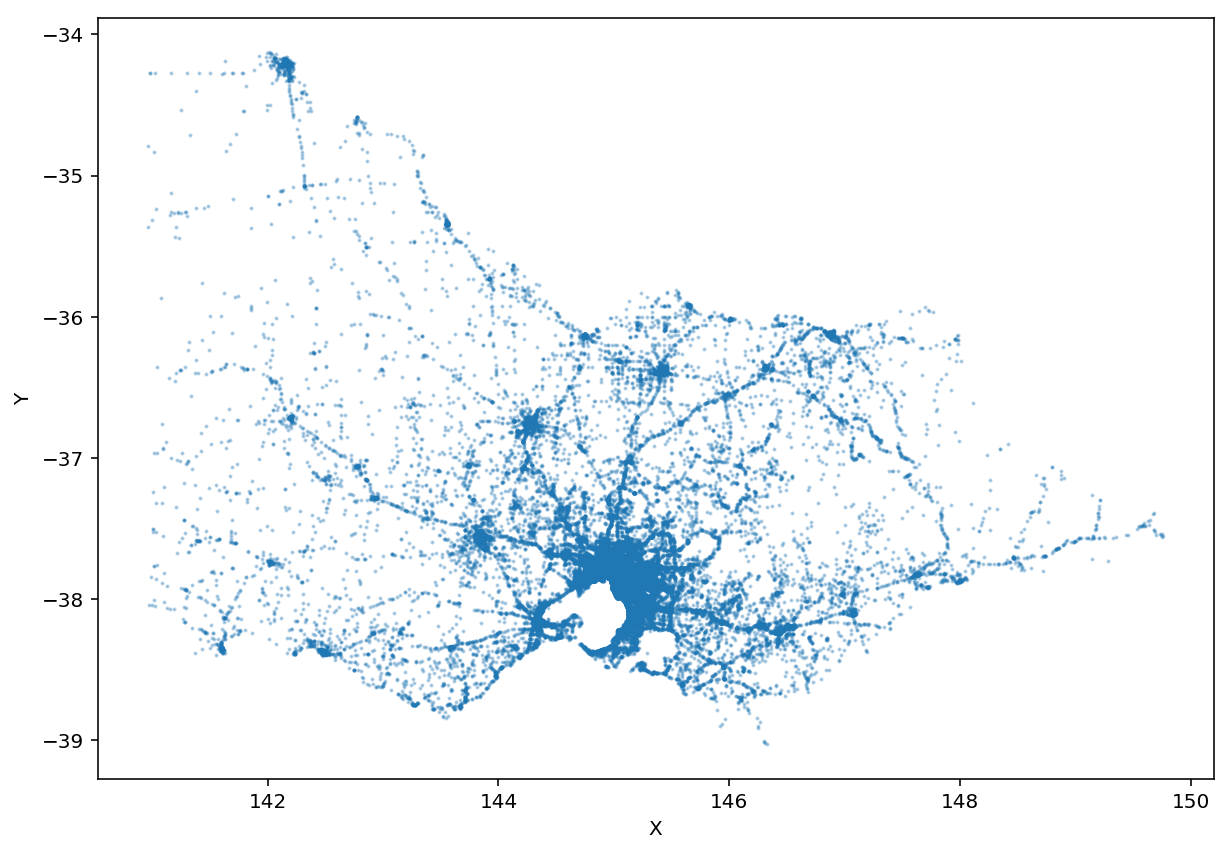

In [2]:
import pandas as pd

accidents = pd.read_csv('Data/traffic/Crashes_Last_Five_Years.csv')
accidents.plot(kind='scatter', x='X', y='Y', figsize=(10, 7), s=1, alpha=0.3)

Even after adjusting the size of the points and the transparency you still lose detail particularly in urban areas.

By comparison, the Datashader library is designed for visualization of large amounts of data. Specifically:

> Datashader is designed to "rasterize" or "aggregate" datasets into regular grids that can be viewed as images, making it simple and quick to see the properties and patterns of your data

In [5]:
import datashader as ds
import datashader.transfer_functions as tf

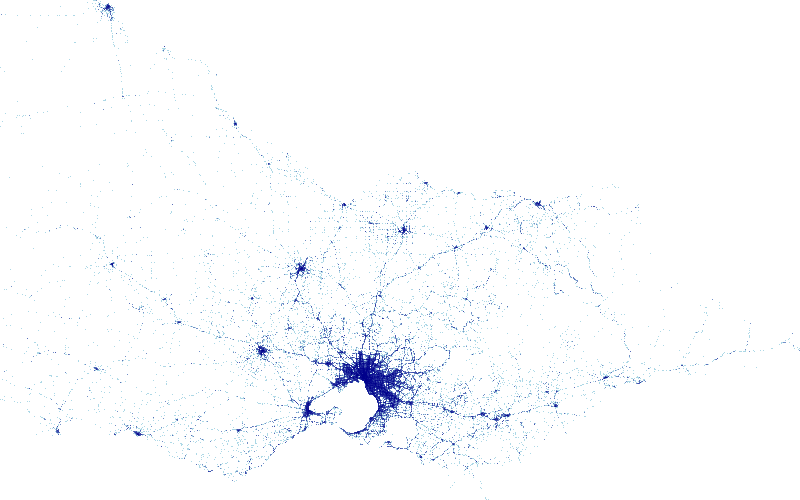

In [6]:
tf.shade(ds.Canvas(800, 500).points(accidents,'X','Y'))

## 5 steps towards data shading

The datashader library accomplishes this through five steps:

1. Projection
2. Aggregation
3. Transformation
4. Colour-mapping
5. Embedding

![](extras/pipeline2.png)

### Projection

The Projection step consists of you deciding which data you want to plot and how you want to plot it. This is done by creating a `Canvas` object which specifies:

- The output width and height of the plot in pixels. The default is for a 600 by 600 pixel plot
- The data x and y limits (the `x_range` and `y_range`). By default this will be taken from the x and y limits of your data
- Whether you want the each axis of the image to be `'linear'` or `'log'`. By default axes will be '`linear`'

In [7]:
scene = ds.Canvas(plot_width=800, plot_height=500)

### Aggregation

Once you have a `Canvas` you can decide how you want to represent your data, as `points`, `lines`, or `raster` methods on the `Canvas`. Along with defining the source dataframe and the x and y columns of your data you must also supply a Reduction which defines how the data in each pixel is aggregated together. You can choose one of:

| Datashader Reduction function | Description |
|-|-|
| `any(column=None)` | Whether any elements in column map to each bin. |
| `count(column=None)` | Count elements in each bin. |
| `count_cat(column)` | Count of all elements in column, grouped by category. The column datatype must be `'category'` |
| `first(column)` | First value encountered in column. |
| `last(column)` | Last value encountered in column. |
| `m2(column)` | Sum of square differences from the mean of all elements in column. |
| `max(column)` | Maximum value of all elements in column. |
| `mean(column)` | Mean of all elements in column. |
| `min(column)` | Minimum value of all elements in column. |
| `mode(column)` | Mode (most common value) of all the values encountered in column. |
| `std(column)` | Standard Deviation of all elements in column. |
| `sum(column)` | Sum of all elements in column. |
| `summary(**kwargs)` | A collection of named reductions. |
| `var(column)` | Variance of all elements in column. |

Note that `NaN` vlues are ignored. If the `agg` keyword argument is not supplied the `count` Reduction is the default.

In [8]:
aggregation = scene.points(accidents, x='X', y='Y', agg=ds.count())

### Transformation

The aggregation is stored as an `xarray.DataArray` or an `xarray.DataSet` depending on the reduction method chosen. This means you can operate on these aggregations in the same way as with any NumPy array or Xarray object to transform the data further as required.

For example, to plot only locations in the upper 1% of the number of accidents:

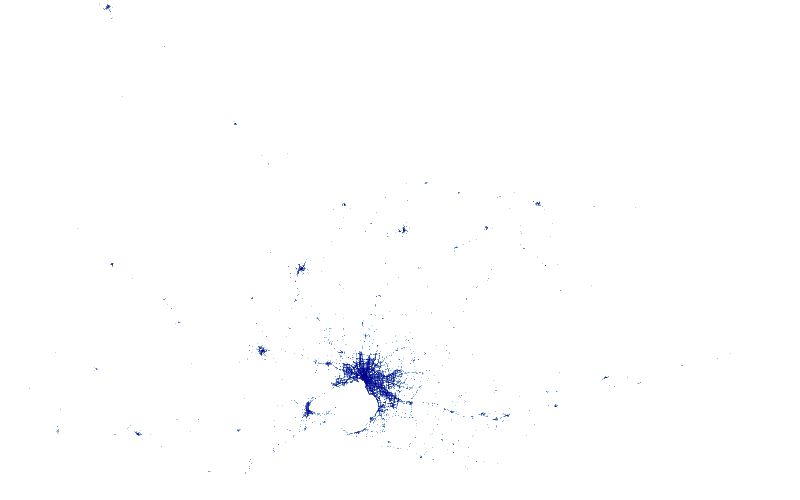

In [9]:
import numpy as np

tf.shade(aggregation.where(aggregation > np.quantile(aggregation, 0.99)))

### Colour-mapping

Once you have finished transforming your data to show the values you're intereted in you can use the `shade` transfer function to map your aggregation to a given colour map. In the Jupyter notebook this returns the image object which is automatically disaplayed (technically the embedding step). If not supplied the default colour map is from lightblue to darkblue. You can choose any set of colours you like whether they are Matplotlib colourmaps, RGB integer triplets, or colour names.

You can also set the interpolation method for the colour bars with the "how" parameter:

| Interpolation method | Description |
|-|-|
| `'eq_hist'` | Equal histograms / percentile (the default) |
| `'cbrt'` | Cube root |
| `'log'` | Logarithmic |
| `'linear'` | Linear interpolation |

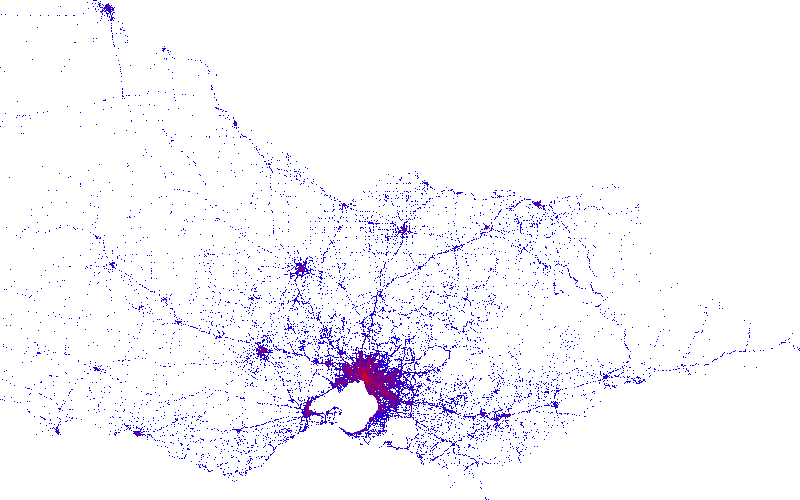

In [10]:
img = tf.shade(aggregation, cmap=['blue', 'red'], how='log')
img

By default the background (`NaN` values in the aggregation object) is transparent, but you can change the background colour easily using another transfer function:

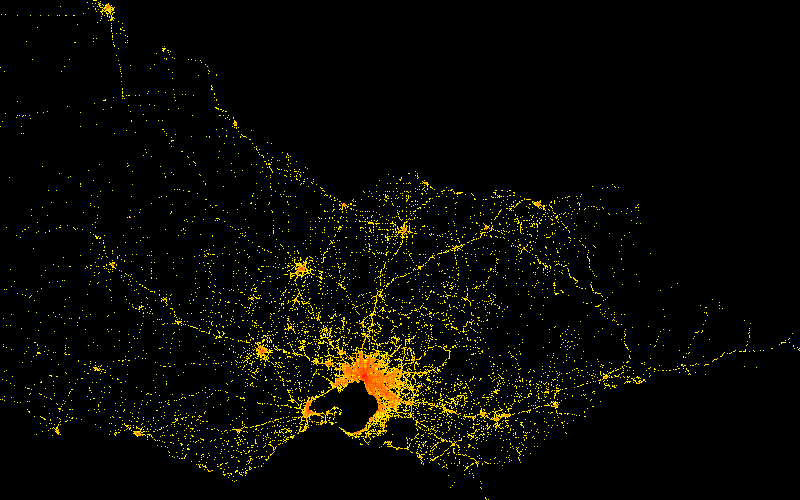

In [11]:
img = tf.shade(aggregation, cmap=['yellow', 'red'], how='log')
tf.set_background(img, color='black')

If you need other colour maps there is a collection available in the `colorcet` library:

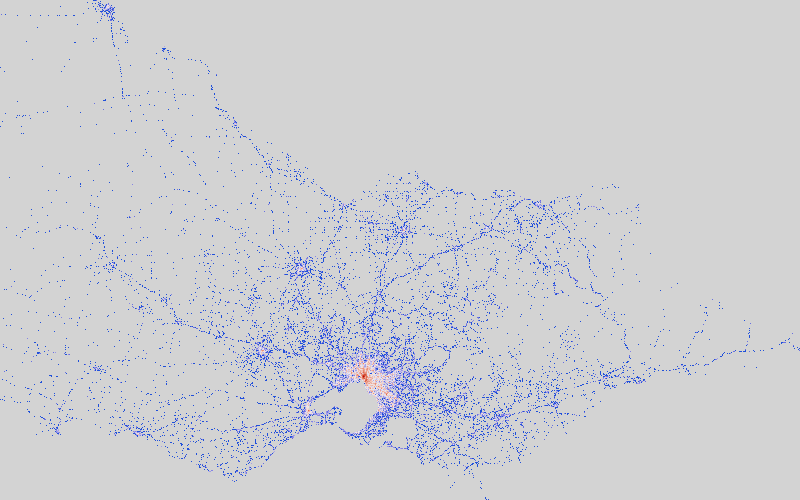

In [12]:
import colorcet

img = tf.shade(aggregation, cmap=colorcet.coolwarm, how='log')
tf.set_background(img, color='lightgrey')

### Embedding

Embedding is the process of displaying the image. Note that by default this is done as soon as you use the `shade` function to create the image. Once you have the `Image` there are other transfer functions you can use to make the image easier to understand:

In [ ]:
tf.Images(
    tf.spread(img, name='spread'),
    tf.dynspread(img, name='dynspread')
)

The `Images` object actually embeds multiple images into a HTML table. If you want to display aacross multiple rows set the `cols` function.

In [ ]:
table = tf.Images(
    tf.spread(img, name='spread'),
    tf.dynspread(img, name='dynspread'),
    tf.spread(img, name='spread 5px', px=5),
    tf.dynspread(img, name='dynspread 0.8 threshold', threshold=0.8)

)
table.cols(2)

Finally, if required you can turn any of these images into a PIL image easily to allow for serialisation on the disk:

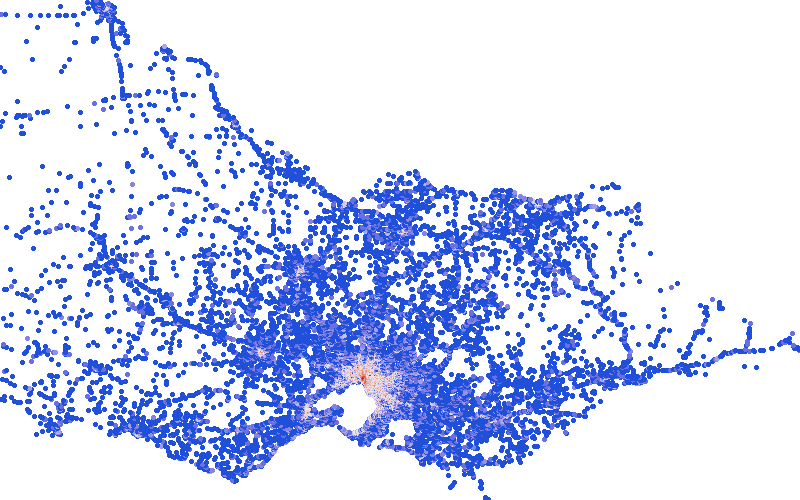

In [16]:
img = tf.dynspread(img, name='dynspread 0.8 threshold', threshold=0.8)
img.to_pil()

### Exercise: Create a plot of the relationship between diameter and shucked weight of abalone

Use pandas to read `Data/abalone.csv` and creaate a plot with the diameter as the x axiss and the shucked weight as the y axis. Rather than simply using aggregating using the count, use the mean aggregation method to take the colour from the rings of the abalone.

Change the colour map from the default to a colour map of your choice from the `colorcet` library.

Finally to make the data easier to read use a spread transfer function to increase the size of the pillows.

In [18]:
# See solutions/datashader_abalone.py

## Visualizing time series and trajectories

Lots of data is easiest to visualize as a continuous value, particularly data with a time-series component. This is still easy to visualize using the datashader library using the line method from the canvas. There is only one change that should happen: at the moment you can't plot dates and times as a dimension directly. Instead you must transform the data into a numeric (e.g. ordinal) value, like so:

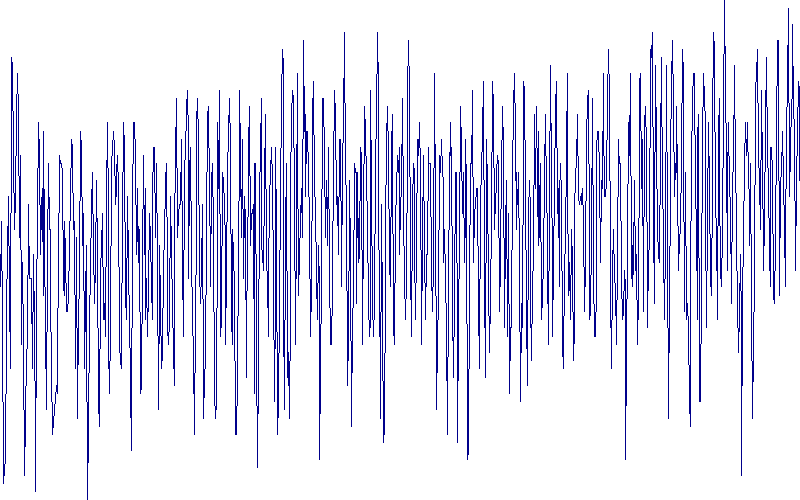

In [19]:
darwin_temperature = pd.read_csv('Data/darwin-temp.csv', parse_dates={'month': ['Year', 'Month']})
darwin_temperature['ordinal month'] = darwin_temperature['month'].apply(lambda d: d.toordinal())
tf.shade(ds.Canvas(800, 500).line(darwin_temperature, 'ordinal month', 'Mean maximum temperature (°C)'))

### Exercise: Plotting a GPS trajectory

Read the `Data/spatial/Quartier_de_Koko_Bouaké.csv` using pandas, parsing the `time` column as a date. Visualize this trail with two line images: one showing the elevation, one showing the time.

In [22]:
# See solutions/datashader_gps.py